
Training AND Gate
Predictions: [0.0, 0.0, 0.0, 1.0]


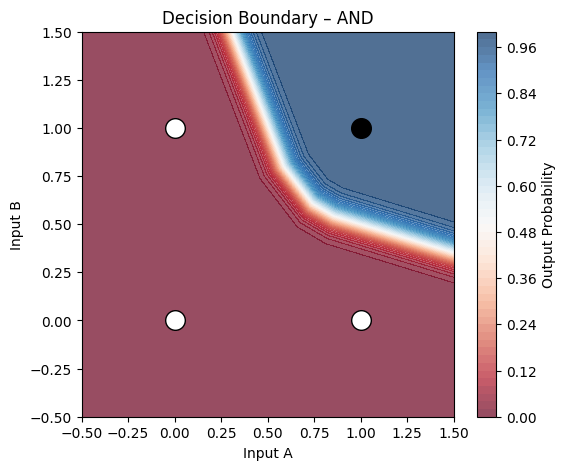


Training OR Gate
Predictions: [0.0, 1.0, 1.0, 1.0]


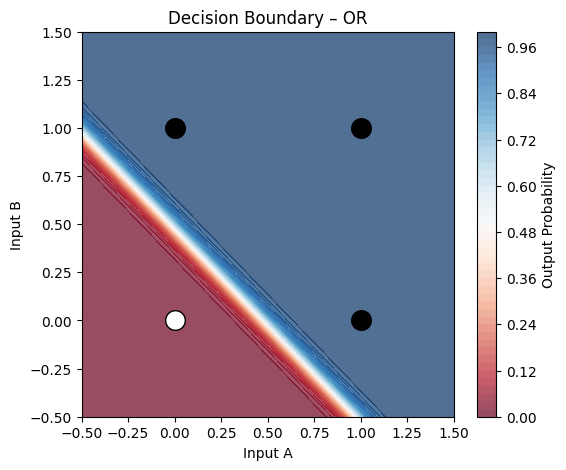


Training NAND Gate
Predictions: [1.0, 1.0, 1.0, 0.0]


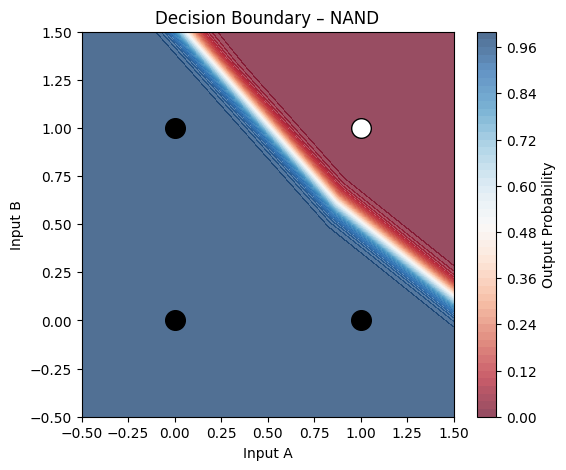


Training NOR Gate
Predictions: [1.0, 0.0, 0.0, 0.0]


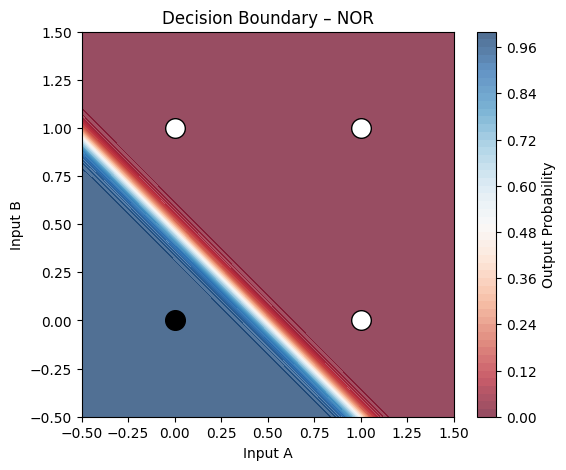


Training XOR Gate
Predictions: [0.0, 1.0, 1.0, 0.0]


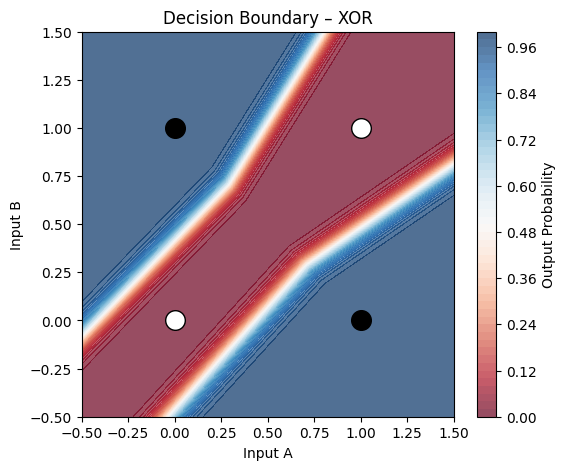


Training XNOR Gate
Predictions: [1.0, 0.0, 0.0, 1.0]


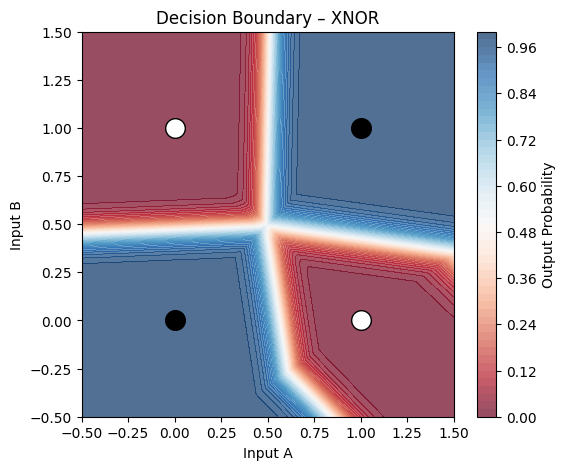

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Dataset
# =========================
X = torch.tensor([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=torch.float32)

gates = {
    "AND":  torch.tensor([[0], [0], [0], [1]], dtype=torch.float32),
    "OR":   torch.tensor([[0], [1], [1], [1]], dtype=torch.float32),
    "NAND": torch.tensor([[1], [1], [1], [0]], dtype=torch.float32),
    "NOR":  torch.tensor([[1], [0], [0], [0]], dtype=torch.float32),
    "XOR":  torch.tensor([[0], [1], [1], [0]], dtype=torch.float32),
    "XNOR": torch.tensor([[1], [0], [0], [1]], dtype=torch.float32)
}

# =========================
# 2. Deep Learning Model
# =========================
class LogicGateNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

# =========================
# 3. Decision Boundary Plot
# =========================
def plot_decision_boundary(model, X, y, gate_name):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, probs, levels=50, cmap="RdBu", alpha=0.7)
    plt.colorbar(label="Output Probability")

    y_np = y.numpy().flatten()
    for i in range(len(X)):
        color = "black" if y_np[i] == 1 else "white"
        plt.scatter(X[i,0], X[i,1], c=color, edgecolors="k", s=200)

    plt.title(f"Decision Boundary – {gate_name}")
    plt.xlabel("Input A")
    plt.ylabel("Input B")
    plt.show()

# =========================
# 4. Train & Test
# =========================
def train_all_gates():
    for gate_name, y in gates.items():
        print(f"\nTraining {gate_name} Gate")

        model = LogicGateNet()
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.05)

        for epoch in range(3000):
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            predictions = torch.sigmoid(model(X)).round()
            print(f"Predictions: {predictions.flatten().tolist()}")

        plot_decision_boundary(model, X, y, gate_name)

# =========================
# 5. Run
# =========================
if __name__ == "__main__":
    train_all_gates()
